# Spatial Correctness and Richness with Joint NDVI + LandCover Analysis

This notebook uses bird occurrence data with both NDVI_raw and LandCover_Class together (jointly), not as isolated single-variable analyses.

Scope:
- Spatial thinning: one record per (district, 5 km cell, species)
- Cell-level bird richness from thinned records
- Joint NDVI + LandCover views of richness
- Interaction model: richness ~ NDVI * LandCover


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42


## 1. Load bird + NDVI_raw + LandCover_Class columns

In [2]:
candidate_paths = [
    Path("file6.csv"),
    Path("../file6.csv"),
    Path("../../file6.csv"),
    Path("final5.csv"),
    Path("../final5.csv"),
    Path("../../final5.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find file6.csv or final5.csv from this notebook location.")

raw = pd.read_csv(data_path, low_memory=False)
required_cols = [
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
    "NDVI_raw",
    "LandCover_Class",
]
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = raw[required_cols].copy()
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
for c in ["decimalLatitude", "decimalLongitude", "NDVI_raw", "LandCover_Class"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["stateProvince"] = df["stateProvince"].astype(str).str.strip()
df["verbatimScientificName"] = df["verbatimScientificName"].astype(str).str.strip()

df = df.dropna(subset=[
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
    "NDVI_raw",
    "LandCover_Class",
])

df["NDVI"] = df["NDVI_raw"] / 10000.0

print(f"Using: {data_path.resolve()}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Districts: {df['stateProvince'].nunique():,}")
print(f"Species: {df['verbatimScientificName'].nunique():,}")
print(f"Land cover classes: {df['LandCover_Class'].nunique():,}")


Using: D:\maneesha\sem04\intro_DS\project\0020473-260226173443078\file6.csv
Rows after cleaning: 1,552,048
Districts: 25
Species: 429
Land cover classes: 11


## 2. Spatial thinning (district, 5 km cell, species)

In [3]:
def add_5km_grid(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    lon0 = float(out["decimalLongitude"].median())
    lat0 = float(out["decimalLatitude"].median())
    lat_rad = np.radians(out["decimalLatitude"].to_numpy())
    out["x_km"] = (out["decimalLongitude"].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
    out["y_km"] = (out["decimalLatitude"].to_numpy() - lat0) * 110.574
    out["grid_x"] = np.floor(out["x_km"] / 5.0).astype(int)
    out["grid_y"] = np.floor(out["y_km"] / 5.0).astype(int)
    out["cell_id"] = (
        out["stateProvince"].astype(str)
        + "|"
        + out["grid_x"].astype(str)
        + "_"
        + out["grid_y"].astype(str)
    )
    return out

def thin_per_species_cell(frame: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    work = frame.copy()
    work["_thin_key"] = (
        work["stateProvince"].astype(str)
        + "|"
        + work["grid_x"].astype(str)
        + "_"
        + work["grid_y"].astype(str)
        + "|"
        + work["verbatimScientificName"].astype(str)
    )
    work["_rand"] = rng.random(len(work))
    return (
        work.sort_values("_rand")
        .groupby("_thin_key", as_index=False)
        .head(1)
        .drop(columns=["_thin_key", "_rand"])
    )

df_grid = add_5km_grid(df)
df_thin = thin_per_species_cell(df_grid, seed=RANDOM_SEED)

print(f"Records before thinning: {len(df_grid):,}")
print(f"Records after thinning:  {len(df_thin):,}")
print(f"Retained fraction:       {len(df_thin)/len(df_grid):.2%}")


Records before thinning: 1,552,048
Records after thinning:  95,608
Retained fraction:       6.16%


## 3. Cell-level table combining richness + NDVI + LandCover

In [4]:
cell_summary = (
    df_thin.groupby(["stateProvince", "cell_id"], as_index=False)
    .agg(
        species_richness=("verbatimScientificName", "nunique"),
        NDVI_mean=("NDVI", "mean"),
    )
)

landcover_mode = (
    df_thin.groupby(["stateProvince", "cell_id"])["LandCover_Class"]
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
    .rename("LandCover_mode")
    .reset_index()
)

cell_summary = cell_summary.merge(landcover_mode, on=["stateProvince", "cell_id"], how="left")
cell_summary = cell_summary.dropna(subset=["NDVI_mean", "LandCover_mode"])
cell_summary["LandCover_mode"] = cell_summary["LandCover_mode"].astype(int).astype(str)

print(f"Cell rows for joint analysis: {len(cell_summary):,}")
print(f"LandCover_mode classes in cells: {cell_summary['LandCover_mode'].nunique()}")
cell_summary.head(10)


Cell rows for joint analysis: 1,740
LandCover_mode classes in cells: 10


,stateProvince,cell_id,species_richness,NDVI_mean,LandCover_mode
0,Ampara,Ampara|14_13,19,0.766400,9
1,Ampara,Ampara|14_17,13,0.806900,14
2,Ampara,Ampara|15_15,47,0.724074,9
3,Ampara,Ampara|17_16,96,0.742879,9
4,Ampara,Ampara|17_17,1,0.821400,9
5,Ampara,Ampara|18_11,4,0.617400,9
6,Ampara,Ampara|19_12,5,0.789400,9
7,Ampara,Ampara|20_10,5,0.734900,9
8,Ampara,Ampara|20_14,26,0.656646,9
9,Ampara,Ampara|21_13,35,0.704734,9


## 4. Joint visualization: richness vs NDVI with LandCover conditioning

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


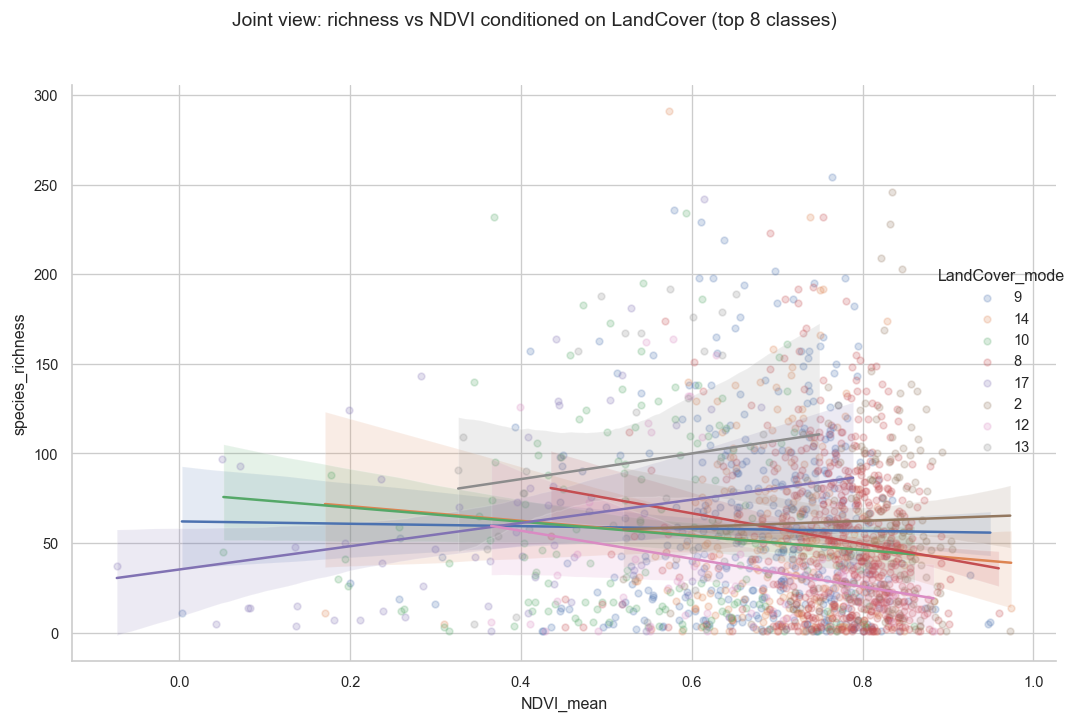

In [5]:
top_k = 8
keep_cover = cell_summary["LandCover_mode"].value_counts().nlargest(top_k).index
plot_joint = cell_summary[cell_summary["LandCover_mode"].isin(keep_cover)].copy()

g = sns.lmplot(
    data=plot_joint,
    x="NDVI_mean",
    y="species_richness",
    hue="LandCover_mode",
    scatter_kws={"alpha": 0.22, "s": 16},
    line_kws={"linewidth": 1.5},
    height=5.8,
    aspect=1.35,
    legend_out=True,
)
g.fig.suptitle(
    f"Joint view: richness vs NDVI conditioned on LandCover (top {top_k} classes)",
    y=1.03,
)
plt.tight_layout()
plt.show()


## 5. Joint matrix view: NDVI bins x LandCover -> mean richness

C:\Users\User\AppData\Local\Temp\ipykernel_32700\3455536190.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(["LandCover_mode", "NDVI_bin"])


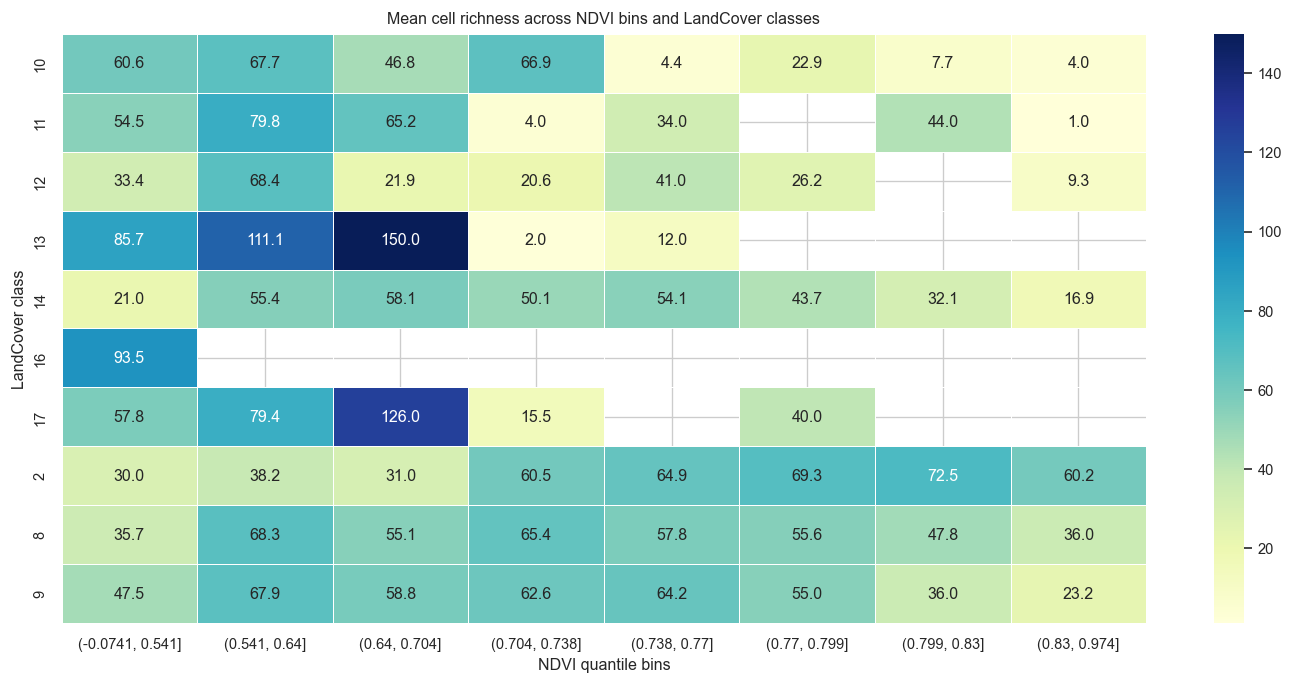

In [6]:
tmp = cell_summary.copy()
tmp["NDVI_bin"] = pd.qcut(tmp["NDVI_mean"], q=8, duplicates="drop")

keep_cover_heat = tmp["LandCover_mode"].value_counts().nlargest(10).index
tmp = tmp[tmp["LandCover_mode"].isin(keep_cover_heat)].copy()

heat = (
    tmp.groupby(["LandCover_mode", "NDVI_bin"])
    .agg(mean_richness=("species_richness", "mean"))
    .reset_index()
    .pivot(index="LandCover_mode", columns="NDVI_bin", values="mean_richness")
)

plt.figure(figsize=(12, 5.8))
sns.heatmap(heat, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=0.4)
plt.title("Mean cell richness across NDVI bins and LandCover classes")
plt.xlabel("NDVI quantile bins")
plt.ylabel("LandCover class")
plt.tight_layout()
plt.show()


## 6. Interaction model (joint effect): richness ~ NDVI * LandCover

In [7]:
model_df = cell_summary.copy()
common_cover = model_df["LandCover_mode"].value_counts().loc[lambda s: s >= 40].index
model_df = model_df[model_df["LandCover_mode"].isin(common_cover)].copy()

fit = smf.ols("species_richness ~ NDVI_mean * C(LandCover_mode)", data=model_df).fit()
print(fit.summary().tables[0])
print(fit.summary().tables[1])

rho, pval = stats.spearmanr(model_df["species_richness"], fit.fittedvalues)
print(f"Spearman(observed richness, fitted richness): r={rho:.3f}, p={pval:.3g}")


                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     2.954
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000279
Time:                        21:00:09   Log-Likelihood:                -8776.8
No. Observations:                1674   AIC:                         1.758e+04
Df Residuals:                    1660   BIC:                         1.766e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

## 7. District-level joint summary (NDVI + LandCover together)

In [8]:
district_cover_share = (
    cell_summary.groupby(["stateProvince", "LandCover_mode"])
    .size()
    .rename("n_cells")
    .reset_index()
)
district_cover_share["cover_share"] = district_cover_share.groupby("stateProvince")["n_cells"].transform(lambda x: x / x.sum())

district_joint = (
    cell_summary.groupby("stateProvince", as_index=False)
    .agg(
        mean_cell_richness=("species_richness", "mean"),
        mean_ndvi=("NDVI_mean", "mean"),
        n_cells=("cell_id", "count"),
    )
    .sort_values("mean_cell_richness", ascending=False)
)

district_joint.head(30)


,stateProvince,mean_cell_richness,mean_ndvi,n_cells
4,Colombo,84.769231,0.648493,39
7,Hambantota,80.955056,0.681635,89
14,Mannar,80.740000,0.516032,50
6,Gampaha,69.720588,0.704577,68
16,Matara,68.947368,0.757809,57
15,Matale,64.485294,0.757818,68
17,Monaragala,59.850000,0.727202,100
21,Puttalam,59.247525,0.654265,101
10,Kandy,58.507042,0.780574,71
8,Jaffna,57.818182,0.467044,55


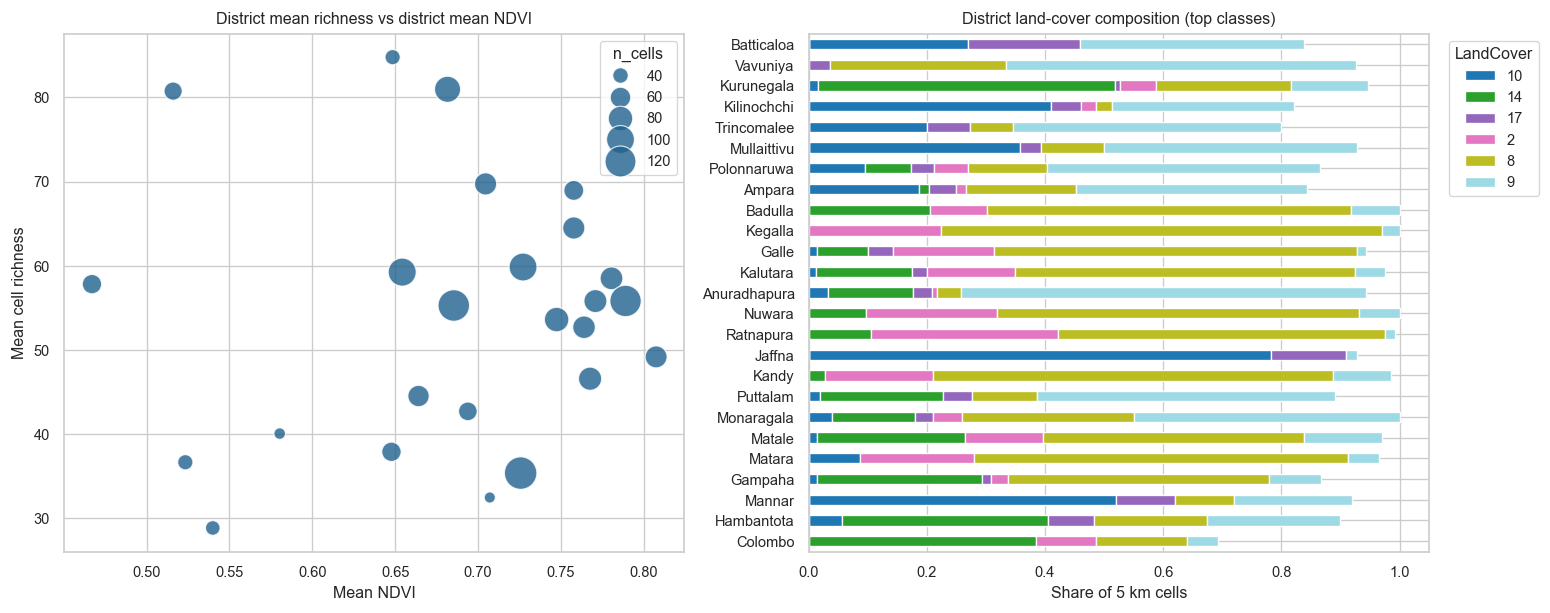

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.scatterplot(
    data=district_joint,
    x="mean_ndvi",
    y="mean_cell_richness",
    size="n_cells",
    sizes=(45, 380),
    color="#1f618d",
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title("District mean richness vs district mean NDVI")
axes[0].set_xlabel("Mean NDVI")
axes[0].set_ylabel("Mean cell richness")

top_cover = district_cover_share["LandCover_mode"].value_counts().nlargest(6).index
cover_plot = district_cover_share[district_cover_share["LandCover_mode"].isin(top_cover)].copy()
pivot_cover = cover_plot.pivot(index="stateProvince", columns="LandCover_mode", values="cover_share").fillna(0)
pivot_cover = pivot_cover.loc[district_joint["stateProvince"]]

pivot_cover.plot(kind="barh", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("District land-cover composition (top classes)")
axes[1].set_xlabel("Share of 5 km cells")
axes[1].set_ylabel("")
axes[1].legend(title="LandCover", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 8. Optional exports

In [10]:
# Uncomment if you want saved tables.
# cell_summary.to_csv("ndvi_landcover_cell_summary.csv", index=False)
# district_joint.to_csv("ndvi_landcover_district_joint_summary.csv", index=False)
# coefs = fit.params.reset_index()
# coefs.columns = ["term", "coef"]
# coefs.to_csv("ndvi_landcover_interaction_coefficients.csv", index=False)
